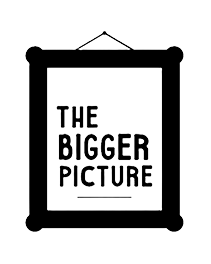

# **Dirección del Episodio**

**Nombre**: [Episodio 2 - Preparamos Los Datasets de 1H y 5M](https://youtu.be/9UiJnNokl2s)

**Objetivo**: Preparar Datasets

**Método**:
*   Completar faltantes en dataset: mediante interpolacion lineal u otra API (Dukascopy).
*   Eliminar duplicados
*   Asegurar integridad de datos entre velas: Modificando 5m OHLC values segun corresponda para matchear las candles de 1H.

**Input file**:
*   Raw_EURUSD.csv
*   Raw_EURUSD_5m.csv

**Output**:
* Source_EURUSD_Mid.csv,
* Source_EURUSD_Mid_5m.csv,

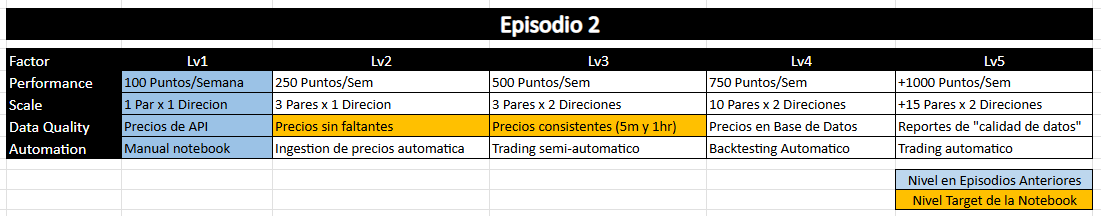

# **1 - Librerias**

In [ ]:
pip install ta

  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=731cdb25d04c1c6926d9c0165e39e3ddd8ada2fffa8637b42e494cd7ebd739e2
  Stored in directory: /root/.cache/pip/wheels/5c/a1/5f/c6b85a7d9452057be4ce68a8e45d77ba34234a6d46581777c6
Successfully built ta


In [ ]:
import os, joblib
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import requests
import lzma
import struct
import time

# **2 - Parametros**

No se necesitan parametros para esta notebook

# **3 -Funciones**

In [ ]:
def get_dukascopy_5m(pair, from_date, to_date, price_type="Bid"):
    from_date = pd.to_datetime(from_date)
    to_date   = pd.to_datetime(to_date)

    price_type = price_type.capitalize()

    if price_type not in ["Bid", "Ask"]:
        raise ValueError("price_type must be 'Bid' or 'Ask'")

    # add 5 minutes internally to complete the last candle
    request_to_date = to_date + pd.Timedelta(minutes=5)

    def get_ticks_for_hour(pair, dt):
        year = dt.year
        month = dt.month - 1  # Dukascopy uses zero-based month
        day = dt.day
        hour = dt.hour

        url = f"https://datafeed.dukascopy.com/datafeed/{pair}/{year}/{month:02d}/{day:02d}/{hour:02d}h_ticks.bi5"

        for attempt in range(5):
            try:
                r = requests.get(url, timeout=60)
                r.raise_for_status()
                break
            except (requests.exceptions.ReadTimeout, requests.exceptions.HTTPError) as e:
                if attempt == 4:
                    raise
                print(f"Request failed, retrying... attempt {attempt + 2}. Error: {e}")
                time.sleep(5)

        data = lzma.decompress(r.content)
        rows = []

        for i in range(0, len(data), 20):
            ms, ask, bid, ask_vol, bid_vol = struct.unpack(">IIIff", data[i:i+20])

            rows.append({
                "Datetime": pd.Timestamp(dt.floor("h")) + pd.to_timedelta(ms, unit="ms"),
                "Bid": bid / 100000,
                "Ask": ask / 100000,
                "BidVolume": bid_vol,
                "AskVolume": ask_vol
            })

        return pd.DataFrame(rows)

    hours = pd.date_range(
        from_date.floor("h"),
        request_to_date.floor("h"),
        freq="h"
    )

    ticks = pd.concat(
        [get_ticks_for_hour(pair, h) for h in hours],
        ignore_index=True
    )

    ticks = (
        ticks[
            (ticks["Datetime"] >= from_date) &
            (ticks["Datetime"] < request_to_date)
        ]
        .set_index("Datetime")
    )

    price_5m = (
        ticks[price_type]
        .resample("5min")
        .ohlc()
        .rename(columns={
            "open": "Open_EURUSD",
            "high": "High_EURUSD",
            "low": "Low_EURUSD",
            "close": "Close_EURUSD"
        })
    )

    price_5m["Volume_EURUSD"] = (
        ticks[f"{price_type}Volume"]
        .resample("5min")
        .sum()
    )

    return price_5m

In [ ]:
def get_discrepacies(mid_1hr_aligned, aggregated_mid_1hr_aligned, currency):
    ohlecv_cols = [f'Open_{currency}', f'High_{currency}', f'Low_{currency}', f'Close_{currency}', f'Volume_{currency}']
    discrepancies_mid = pd.DataFrame()

    for col in ohlecv_cols:
      mask = ~(
          mid_1hr_aligned[col].round(5).fillna(0)
          == aggregated_mid_1hr_aligned[col].round(5).fillna(0)
      )

      print(f"Number of discrepancies found for {col}: {mask.sum()}")
      df = pd.DataFrame()

      if mask.any():
          discrepant_indices = mask[mask].index
          df = pd.DataFrame(index=discrepant_indices)
          df["col"] = col
          df["source_1hr"] = mid_1hr_aligned.loc[discrepant_indices, col]
          df["agg_5m"] = aggregated_mid_1hr_aligned.loc[discrepant_indices, col]
          if col != 'Volume_EURUSD':
              df["diff_points"] = (df["source_1hr"] - df["agg_5m"]) * 100000
          else:
              df["diff_points"] = (df["source_1hr"] - df["agg_5m"])
          df["diff_points"] = df["diff_points"].round().astype('int64')
          df["WasMissing"] = aggregated_mid_1hr_aligned.loc[discrepant_indices, "WasMissing"]
          discrepancies_mid = pd.concat([discrepancies_mid, df])
      # else:
      #     print(f"No discrepancies found for {col}.")

    return discrepancies_mid

In [ ]:
def get_week_fields(datetime_values):
    # Custom trading week logic:
    # - Weeks start on Sunday.
    # - YYYY comes from Week_Start.year.
    # - Week 1 starts on the first Sunday AFTER Jan 1 of that Week_Start.year.
    # - This avoids week 0 and keeps Jan 1 out of Week 1.
    # - Returns week and YYYYWW using the same logic.

    dates = pd.to_datetime(datetime_values)

    if isinstance(dates, pd.Series):
        result = pd.DataFrame(index=datetime_values.index)
        dates_series = dates
    elif isinstance(dates, pd.DatetimeIndex):
        result = pd.DataFrame(index=datetime_values)
        dates_series = pd.Series(dates, index=datetime_values)
    else:
        date = pd.to_datetime(datetime_values)

        week_start = date.to_period("W-SAT").start_time
        year = week_start.year

        jan1 = pd.Timestamp(year=year, month=1, day=1)
        days_to_sunday = (6 - jan1.weekday()) % 7

        if days_to_sunday == 0:
            days_to_sunday = 7

        first_sunday = jan1 + pd.Timedelta(days=days_to_sunday)

        week = ((week_start - first_sunday).days // 7) + 1
        yyyyww = f"{year}{week:02d}"

        return week, yyyyww

    week_start = dates_series.dt.to_period("W-SAT").dt.start_time
    year = week_start.dt.year

    jan1 = pd.to_datetime(year.astype(str) + "-01-01")
    days_to_sunday = (6 - jan1.dt.weekday) % 7
    days_to_sunday = days_to_sunday.mask(days_to_sunday == 0, 7)

    first_sunday = jan1 + pd.to_timedelta(days_to_sunday, unit="D")

    week = ((week_start - first_sunday).dt.days // 7) + 1

    result["week"] = week.astype(int)
    result["YYYYWW"] = year.astype(str) + result["week"].astype(str).str.zfill(2)

    return result

In [ ]:
def filter_market_hours(df, freq):
    print(f'df size before filter_market_hours(): {len(df)}')
    # get min and max
    min_df = df.index.min()
    max_df = df.index.max()

    # get full range
    full_datetime_index = pd.date_range(
        start=min_df,
        end=max_df,
        freq=freq
    )

    # market calendar
    market_calendar_df = pd.DataFrame(index=full_datetime_index)

    # treat index as UTC, but DO NOT change the index
    utc_datetime = market_calendar_df.index.tz_localize('UTC')
    ny_datetime  = utc_datetime.tz_convert('America/New_York')

    market_calendar_df['UTC_Date']    = utc_datetime.date
    market_calendar_df['NY_Datetime'] = ny_datetime
    market_calendar_df['NY_Weekday']  = ny_datetime.weekday
    market_calendar_df['NY_Hour']     = ny_datetime.hour
    market_calendar_df['NY_Date']     = ny_datetime.date

    # Week Start based on UTC_Date, Sunday as first day of week
    market_calendar_df['Week_Start'] = (
        pd.to_datetime(market_calendar_df['UTC_Date'])
        .dt.to_period('W-SAT')
        .dt.start_time
    )


    market_calendar_df["Week_Number"] = get_week_fields(market_calendar_df["Week_Start"])["week"].values

    # exclude weeks 51 and 52
    # is_excluded_week = market_calendar_df["Week_Number"] > 50
    is_excluded_week = (
            (market_calendar_df["Week_Number"] < 1) |
            (market_calendar_df["Week_Number"] > 50)
        )

    # OpenMarketFlag :Domingos desde las 20, Friday open until 16 y las semanas 51 y 52 del año no se tradean
    market_calendar_df['OpenMarketFlag'] = (
        (
            ((market_calendar_df['NY_Weekday'] == 6) & (market_calendar_df['NY_Hour'] >= 20)) | # Sunday desde las 20
            market_calendar_df['NY_Weekday'].between(0, 3) |
            ((market_calendar_df['NY_Weekday'] == 4) & (market_calendar_df['NY_Hour'] <= 16))  # Friday open until 16 NY for H1 candles
        ) &
        (~is_excluded_week) # exclude weeks 51 and 52
    ).astype(int)

    # keep only expected open-market datetimes
    open_market_index = market_calendar_df.loc[
        market_calendar_df['OpenMarketFlag'] == 1
    ].index

    # reindex only open-market hours
    df_full = df.reindex(open_market_index)
    df_full.index.name = 'Datetime'

    # missing
    price_cols = ["Open_EURUSD", "High_EURUSD", "Low_EURUSD", "Close_EURUSD","Volume_EURUSD"]
    price_missing_mask = df_full[price_cols].isna().all(axis=1)
    missing_rows = df_full[price_missing_mask].copy()
    # missing_rows = df_full[df_full.isna().all(axis=1)].copy()
    missing_rows['Year'] = missing_rows.index.year
    missing_rows['Weekday'] = missing_rows.index.weekday
    missing_rows['Hour'] = missing_rows.index.hour
    # df_full['is_missing'] = df_full['Close_EURUSD'].isna()
    df_full["is_missing"] = price_missing_mask

    # printing
    print(f'Missing rows: {len(missing_rows)}')
    print('Market_hours: Domingos desde las 20 NY Time, Friday open hasta 16 NY Time. Ademas, las semanas 51 y 52 del año no se tradean')
    print(f'df size after filter_market_hours(): {len(df_full)}')
    return df_full, missing_rows

In [ ]:
def aggregate_5m_to_1h(df_5m, prefix='EURUSD'):
    # Ensure the index is a DatetimeIndex
    if not isinstance(df_5m.index, pd.DatetimeIndex):
        df_5m.index = pd.to_datetime(df_5m.index)

    # Group by hourly periods and aggregate
    aggregated_df = df_5m.resample('1h').agg({ # Changed '1H' to '1h'
        f'Open_{prefix}': 'first',
        f'High_{prefix}': 'max',
        f'Low_{prefix}': 'min',
        f'Close_{prefix}': 'last',
        f'Volume_{prefix}': 'sum',
        f'WasMissing':'max'
    })
    # elimina una fila solo si Open, High, Low y Close son todos nulos en esa fila.
    aggregated_df = aggregated_df.dropna(
        subset=[
            f'Open_{prefix}',
            f'High_{prefix}',
            f'Low_{prefix}',
            f'Close_{prefix}'
        ],
        how="all"
    )

    return aggregated_df

# aggregated_mid_1hr = aggregate_5m_to_1h(intermediate_mid5, currency)
# aggregated_mid_1hr.loc["2022-05-04 15:00:00":"2022-05-04 21:00:00"]

In [ ]:
# intermediate_mid5[(intermediate_mid5['WasMissing']==True)&(intermediate_mid5['FilledMethod']!='linear_interpolation')].head(20)
# linear_interpolation = 2021-08-02 21:10:00
# dukascopy_ticks = 2022-05-04 18:40:00

# **4 - Preparo Dataset 1H**

Importo raw data

In [ ]:
## importar ask prices
mid_df = pd.read_csv('Raw_EURUSD.csv')
print(f"Successfully loaded {len(mid_df)} rows from EURUSD_Ask.csv")

# Convert 'Datetime' column to datetime objects and set as index
mid_df['Datetime'] = pd.to_datetime(mid_df['Datetime'])
mid_df = mid_df.set_index('Datetime')

# reemplazo volumne = 0 by Nan
mid_df["Volume_EURUSD"] = mid_df["Volume_EURUSD"].replace(0, np.nan)

# comienzo mi semana un domingo y la termino un sabado para manejar solo semanas con todos los dias.
start_date = "2021-08-01 00:00:00"
end_date = "2026-05-02 23:59:59"
mid_df = mid_df.loc[start_date:]
mid_df = mid_df.loc[:end_date]
print(f'start_date is {pd.to_datetime(start_date).day_name()} and should be Sunday')
print(f'end_date is {pd.to_datetime(end_date).day_name()} and should be Saturday')

# check duplicates
counts = mid_df.index.value_counts(dropna=False)
print(f'Total duplicates {len(counts[counts > 1])}')
display(mid_df.head(2))

# cleaned
mid_df_verified = mid_df.copy()

Successfully loaded 33283 rows from EURUSD_Ask.csv
start_date is Sunday and should be Sunday
end_date is Saturday and should be Saturday
Total duplicates 0


,Open_EURUSD,High_EURUSD,Low_EURUSD,Close_EURUSD,Volume_EURUSD
Datetime,,,,,
2021-08-01 21:00:00,1.18623,1.18702,1.18623,1.18655,47.0
2021-08-01 22:00:00,1.18659,1.18697,1.18634,1.18683,381.0


Filtro la semana segun Market_hours y obtengo los datetimes faltantes (NaN values)

In [ ]:
# Market_hours: Domingos desde las 20, Friday open until 16 y las semanas 51 y 52 del año no se tradean
mid_df_full, missing_rows = filter_market_hours(df = mid_df_verified, freq = 'h')
display(mid_df_full['is_missing'].value_counts(dropna=False))
display(mid_df_full[mid_df_full['is_missing']==True].head(2))

df size before filter_market_hours(): 29589
Missing rows: 2
Market_hours: Domingos desde las 20 NY Time, Friday open hasta 16 NY Time. Ademas, las semanas 51 y 52 del año no se tradean
df size after filter_market_hours(): 27729


,count
is_missing,
False,27727
True,2


,Open_EURUSD,High_EURUSD,Low_EURUSD,Close_EURUSD,Volume_EURUSD,is_missing
Datetime,,,,,,
2022-05-12 06:00:00,NaN,NaN,NaN,NaN,NaN,True
2022-05-12 07:00:00,NaN,NaN,NaN,NaN,NaN,True


Lo anterior define como missing cuando todas las columnas son nullas. Pero hay casos en los que solo el volumen es null. Para esos casos aplico interpolacion

In [ ]:
# print
columns = ['Open_EURUSD', 'High_EURUSD', 'Low_EURUSD', 'Close_EURUSD', 'Volume_EURUSD']
solo_vol_empty = mid_df_full[(mid_df_full["Volume_EURUSD"].isna())&(mid_df_full[columns].notna().any(axis=1) )]
print(f'Filas con SOLO el Volumne empty total:{len(solo_vol_empty)}')
display(solo_vol_empty)

# interpolation
volume_missing_mask = mid_df_full["Volume_EURUSD"].isna()
mid_df_full.loc[volume_missing_mask, "Volume_EURUSD"] = (
    mid_df_full["Volume_EURUSD"]
    .interpolate(method="time")
    .loc[volume_missing_mask]
)
solo_vol_empty = mid_df_full[(mid_df_full["Volume_EURUSD"].isna())&(mid_df_full[columns].notna().any(axis=1) )]
print(f'\nFilas con SOLO el Volumne empty despues de la interpolacion total:{len(solo_vol_empty)}')
display(mid_df_full[(mid_df_full["Volume_EURUSD"].isna())&(mid_df_full[columns].notna().any(axis=1) )])


Filas con SOLO el Volumne empty total:2


,Open_EURUSD,High_EURUSD,Low_EURUSD,Close_EURUSD,Volume_EURUSD,is_missing
Datetime,,,,,,
2024-05-20 15:00:00,1.08672,1.08672,1.08613,1.08625,NaN,False
2024-05-20 16:00:00,1.08637,1.08684,1.08625,1.08684,NaN,False



Filas con SOLO el Volumne empty despues de la interpolacion total:0


,Open_EURUSD,High_EURUSD,Low_EURUSD,Close_EURUSD,Volume_EURUSD,is_missing
Datetime,,,,,,


Proximo pasos:
*   Clasifico los gaps segun la cantidad de horas faltantes: small_missing_mask & large_missing_mask
*   small_missing_mask: Lo completo usando iterpolacion lineal
*   large_missing_mask: lo completo con una nueva API




In [ ]:
# gap id for every consecutive block
gap_id = (
    mid_df_full['is_missing']
    .ne(mid_df_full['is_missing'].shift())
    .cumsum()
)

missing_gaps = (
    mid_df_full[mid_df_full["is_missing"]]
    .groupby(gap_id)
    .apply(lambda x: pd.Series({
        "start": x.index.min(),
        "end": x.index.max(),
        "rows": len(x)
    }))
    .reset_index(names="gap_id")
)

# only gaps bigger than 3 candles
large_missing_gaps = missing_gaps[missing_gaps['rows'] > 3].copy()
print(f'Large gaps {len(large_missing_gaps)}')
display(large_missing_gaps.head(3))

small_missing_gaps = missing_gaps[missing_gaps['rows'] <= 3].copy()
print(f'\nSmall gaps {len(small_missing_gaps)}')
display(small_missing_gaps.head(3))

Large gaps 0


,gap_id,start,end,rows



Small gaps 1


,gap_id,start,end,rows
0,2,2022-05-12 06:00:00,2022-05-12 07:00:00,2


In [ ]:
## SMALL Gaps
small_gap_ids = small_missing_gaps["gap_id"]

small_missing_mask = (
    mid_df_full["is_missing"] &
    gap_id.isin(small_gap_ids)
)

price_cols = [
    'Open_EURUSD',
    'High_EURUSD',
    'Low_EURUSD',
    'Close_EURUSD',
    'Volume_EURUSD'
]
mid_df_full['FilledMethod'] = None
mid_df_full['WasMissing'] = mid_df_full['is_missing']

# linear interpolation only for small missing gaps
mid_df_full.loc[small_missing_mask, price_cols] = (
    mid_df_full[price_cols]
    .interpolate(method='time')
    .loc[small_missing_mask, price_cols]
)
mid_df_full.loc[small_missing_mask, 'FilledMethod'] = 'linear_interpolation'

# update current missing status after fill
mid_df_full["is_missing"] = mid_df_full[price_cols].isna().all(axis=1)

# completo NaN con niinguno
mid_df_full["FilledMethod"] = mid_df_full["FilledMethod"].fillna("Ninguno")

# validation
print(mid_df_full[['WasMissing','FilledMethod','is_missing']].value_counts(dropna=False))

WasMissing  FilledMethod  is_missing
False       Ninguno       False         27729
Name: count, dtype: int64


In [ ]:
# Chequeo final: Me aseguro que todas las semanas tengan 117 horas.
df_temp = mid_df_full.copy()
df_temp['YYYYWW'] =  get_week_fields(df_temp.index)['YYYYWW']

weekly_counts = df_temp.groupby(['YYYYWW']).size().reset_index(name='total_candles')

for index, row in weekly_counts.iterrows():
    if row['total_candles'] != 117:
      print(f"{row['year']}{row['week']:02d} {row['total_candles']}")

print(f'Cantidad total de NULLs diferenciado por columna: \n{df_temp.isna().sum()}')

Cantidad total de NULLs: 
Open_EURUSD      0
High_EURUSD      0
Low_EURUSD       0
Close_EURUSD     0
Volume_EURUSD    0
is_missing       0
FilledMethod     0
WasMissing       0
YYYYWW           0
dtype: int64


In [ ]:
# genero csv intermedio para no rerun esto de nuevo
mid_df_full.to_csv('Intermediate_EURUSD_Mid.csv')
print(len(mid_df_full))

27729


# **5 - Preparo Dataset M5**

In [ ]:
## importar ask prices
mid5_df = pd.read_csv('Raw_EURUSD_5m.csv')
print(f"Successfully loaded {len(mid5_df)} rows from Raw_EURUSD_5m.csv")

# Convert 'Datetime' column to datetime objects and set as index
mid5_df['Datetime'] = pd.to_datetime(mid5_df['Datetime'])
mid5_df = mid5_df.set_index('Datetime')

# comienzo mi semana un domingo y la termino un sabado para manejar solo semanas con todos los dias.
start_date = "2021-08-01 00:00:00"
end_date = "2026-05-02 23:59:59"
mid5_df = mid5_df.loc[start_date:]
mid5_df = mid5_df.loc[:end_date]
print(f'start_date is {pd.to_datetime(start_date).day_name()} and should be Sunday')
print(f'end_date is {pd.to_datetime(end_date).day_name()} and should be Saturday')

# check duplicates
counts = mid5_df.index.value_counts(dropna=False)
print(f'Total duplicates {len(counts[counts > 1])}')

# cleaned
mid5_df_verified = mid5_df.copy()

Successfully loaded 356360 rows from Raw_EURUSD_5m.csv
start_date is Sunday and should be Sunday
end_date is Saturday and should be Saturday
Total duplicates 0


In [ ]:
# Market_hours :Domingos desde las 20, Friday open until 16 y las semanas 51 y 52 del año no se tradean
mid5_df_full, missing_rows = filter_market_hours(df = mid5_df_verified, freq = '5min')
display(mid5_df_full['is_missing'].value_counts(dropna=False))

df size before filter_market_hours(): 354694
Missing rows: 213
Market_hours: Domingos desde las 20 NY Time, Friday open hasta 16 NY Time. Ademas, las semanas 51 y 52 del año no se tradean
df size after filter_market_hours(): 332748


,count
is_missing,
False,332535
True,213


Encuentro los gaps y los diferencio

In [ ]:
# gap id for every consecutive block
gap_id = (
    mid5_df_full['is_missing']
    .ne(mid5_df_full['is_missing'].shift())
    .cumsum()
)

missing_gaps = (
    mid5_df_full[mid5_df_full["is_missing"]]
    .groupby(gap_id)
    .apply(lambda x: pd.Series({
        "start": x.index.min(),
        "end": x.index.max(),
        "rows": len(x)
    }))
    .reset_index(names="gap_id")
)


# only gaps bigger than 3 candles
large_missing_gaps = missing_gaps[missing_gaps['rows'] > 3].copy()
print('Large gaps')
display(large_missing_gaps.head(3))

small_missing_gaps = missing_gaps[missing_gaps['rows'] <= 3].copy()
print('Small gaps')
display(small_missing_gaps.head(3))

Large gaps


,gap_id,start,end,rows
90,182,2022-05-04 18:40:00,2022-05-04 19:05:00,6
95,192,2022-05-12 05:20:00,2022-05-12 08:00:00,33
110,222,2024-05-20 14:25:00,2024-05-20 17:15:00,35


Small gaps


,gap_id,start,end,rows
0,2,2021-08-02 21:10:00,2021-08-02 21:10:00,1
1,4,2021-08-03 21:25:00,2021-08-03 21:25:00,1
2,6,2021-08-03 21:35:00,2021-08-03 21:35:00,1


In [ ]:
## SMALL Gaps
small_gap_ids = small_missing_gaps["gap_id"]

small_missing_mask = (
    mid5_df_full["is_missing"] &
    gap_id.isin(small_gap_ids)
)

price_cols = [
    'Open_EURUSD',
    'High_EURUSD',
    'Low_EURUSD',
    'Close_EURUSD',
    'Volume_EURUSD'
]
mid5_df_full['FilledMethod'] = None
mid5_df_full['WasMissing'] = mid5_df_full['is_missing']

# linear interpolation only for small missing gaps
mid5_df_full.loc[small_missing_mask, price_cols] = (
    mid5_df_full[price_cols]
    .interpolate(method='time')
    .loc[small_missing_mask, price_cols]
)
mid5_df_full.loc[small_missing_mask, 'FilledMethod'] = 'linear_interpolation'

# update current missing status after fill
mid5_df_full["is_missing"] = mid5_df_full[price_cols].isna().all(axis=1)

# validation
print(mid5_df_full[['WasMissing','FilledMethod','is_missing']].value_counts(dropna=False))

WasMissing  FilledMethod          is_missing
False       NaN                   False         332535
True        linear_interpolation  False            139
            NaN                   True              74
Name: count, dtype: int64


In [ ]:
# ## Large gaps
dukascopy_results_mid = []
for _, gap in large_missing_gaps.iterrows():
    print(f"Downloading: {gap['start']} -> {gap['end']}")

    gap_data_ask = get_dukascopy_5m(
        pair='EURUSD',
        from_date=gap['start'],
        to_date=gap['end'],
        price_type="Ask"
    )
    gap_data_bid = get_dukascopy_5m(
        pair='EURUSD',
        from_date=gap['start'],
        to_date=gap['end'],
        price_type="Bid"
    )

    price_cols = ['Open_EURUSD', 'High_EURUSD', 'Low_EURUSD', 'Close_EURUSD', 'Volume_EURUSD']
    gap_data = (gap_data_ask[price_cols] + gap_data_bid[price_cols]) / 2

    dukascopy_results_mid.append(gap_data)


dukascopy_mid_missing_5m = pd.concat(dukascopy_results_mid)

In [ ]:
# Agrego las filas a mid5_df_full
fill_index = mid5_df_full.index[
    mid5_df_full['is_missing'] &
    mid5_df_full.index.isin(dukascopy_mid_missing_5m.index)
]
mid5_df_full.loc[fill_index, price_cols] = (
    dukascopy_mid_missing_5m.loc[fill_index, price_cols]
)

mid5_df_full.loc[fill_index, 'FilledMethod'] = 'dukascopy_ticks'
mid5_df_full["is_missing"] = mid5_df_full[price_cols].isna().all(axis=1)
mid5_df_full['FilledMethod'].value_counts(dropna=False)

,count
FilledMethod,
None,332535
linear_interpolation,139
dukascopy_ticks,74


In [ ]:
print(mid5_df_full[['WasMissing','FilledMethod','is_missing']].value_counts(dropna=False))

WasMissing  FilledMethod          is_missing
False       NaN                   False         332535
True        linear_interpolation  False            139
            dukascopy_ticks       False             74
Name: count, dtype: int64


In [ ]:
# Chequeo que no haya faltantes
df_temp = mid5_df_full.copy()
df_temp['YYYYWW'] =  get_week_fields(df_temp.index)['YYYYWW']

weekly_counts = df_temp.groupby(['YYYYWW']).size().reset_index(name='total_candles')

for index, row in weekly_counts.iterrows():
    if row['total_candles'] != 1404:
      print(f"{row['YYYYWW']} {row['total_candles']}")

In [ ]:
mid5_df_full.to_csv('Intermediate_EURUSD_Mid_5m.csv')
print(len(mid5_df_full))

332748


# **6 - Reconciliation 1H y 5m**

In [ ]:
# import
intermediate_mid = pd.read_csv('Intermediate_EURUSD_Mid.csv', index_col=0, parse_dates=True, low_memory=False)
intermediate_mid5 = pd.read_csv('Intermediate_EURUSD_Mid_5m.csv', index_col=0, parse_dates=True, low_memory=False)

# Aggregate 5-minute ask data to 1-hour
currency = 'EURUSD'
aggregated_mid_1hr = aggregate_5m_to_1h(intermediate_mid5, currency)

# Get intersection index
common_index_mid = intermediate_mid.index.intersection(aggregated_mid_1hr.index)

# Filter by new index
mid_1hr_aligned = intermediate_mid.loc[common_index_mid]
aggregated_mid_1hr_aligned = aggregated_mid_1hr.loc[common_index_mid]

# prints
print(f"intermediate_mid5 size: {len(intermediate_mid5):,} --> traget size = size/12 = {(len(intermediate_mid5)/12):,}")
print(f"aggregated_mid_1hr size: {len(aggregated_mid_1hr):,}")
print(f"intermediate_mid size: {len(intermediate_mid):,}")
print(f"aggregated_mid_1hr_aligned size (after filtering by common_index_mid): {len(aggregated_mid_1hr_aligned):,}")
print(f"mid_1hr_aligned size (after filtering by common_index_mid): {len(mid_1hr_aligned):,}")

# analisis of discrepancies
discrepancies_mid = get_discrepacies(mid_1hr_aligned, aggregated_mid_1hr_aligned, currency)
print(f'Total discrepancies_mid found: {len(discrepancies_mid)}\n')
print(discrepancies_mid[['WasMissing']].value_counts(dropna=False))
discrepancies_mid.head(2)

intermediate_mid5 size: 332,748 --> traget size = size/12 = 27,729.0
aggregated_mid_1hr size: 27,729
intermediate_mid size: 27,729
aggregated_mid_1hr_aligned size (after filtering by common_index_mid): 27,729
mid_1hr_aligned size (after filtering by common_index_mid): 27,729
Number of discrepancies found for Open_EURUSD: 7
Number of discrepancies found for High_EURUSD: 9
Number of discrepancies found for Low_EURUSD: 5
Number of discrepancies found for Close_EURUSD: 9
Number of discrepancies found for Volume_EURUSD: 109
Total discrepancies_mid found: 139

WasMissing
1.0           139
Name: count, dtype: int64


,col,source_1hr,agg_5m,diff_points,WasMissing
Datetime,,,,,
2022-05-04 19:00:00,Open_EURUSD,1.052070,1.061615,-954,1.0
2022-05-12 06:00:00,Open_EURUSD,1.049773,1.050140,-37,1.0


Estrategia:
*   Open & Close: Reemplazo por Oanda value
*   High & low, tomo Onda h y lo reemplazo en el valor mas alto de la serie. Lo mismo con el Low.
*   Volume: Cuando 1H tiene volumen no hace falta ajustar. Ya que volumen de 5m no se usa para entrenar el modelo.



In [ ]:
# copy()
discrepancies_mid_aux = discrepancies_mid.copy()
source_1h = mid_1hr_aligned.copy()
source_5m_fixed = intermediate_mid5.copy()

# Open
open_index = discrepancies_mid_aux[discrepancies_mid_aux['col']== 'Open_EURUSD'].index
source_5m_fixed.loc[open_index,'Open_EURUSD'] = source_1h.loc[open_index,'Open_EURUSD']
# agg_1hr_fixed = aggregate_5m_to_1h(source_5m_fixed, currency)
# discrepancies_mid_aux = get_discrepacies(source_1h, agg_1hr_fixed, currency)
# print(f'Total discrepancies_mid found: {len(discrepancies_mid_aux)}\n')

# Close
close_index = discrepancies_mid_aux[discrepancies_mid_aux["col"] == "Close_EURUSD"].index
target_index = close_index + pd.Timedelta(minutes=55)
source_5m_fixed.loc[target_index, "Close_EURUSD"] = source_1h.loc[close_index, "Close_EURUSD"].values
agg_1hr_fixed = aggregate_5m_to_1h(source_5m_fixed, currency)
discrepancies_mid_aux = get_discrepacies(source_1h, agg_1hr_fixed, currency)
print(f'Total discrepancies_mid found: {len(discrepancies_mid_aux)}\n')

Number of discrepancies found for Open_EURUSD: 0
Number of discrepancies found for High_EURUSD: 9
Number of discrepancies found for Low_EURUSD: 5
Number of discrepancies found for Close_EURUSD: 0
Number of discrepancies found for Volume_EURUSD: 109
Total discrepancies_mid found: 123



In [ ]:
# High
high_index = discrepancies_mid_aux[discrepancies_mid_aux["col"] == "High_EURUSD"].index
for from_date in high_index:
    to_date = from_date + pd.Timedelta(minutes=55)
    max_price = source_1h.loc[from_date, "High_EURUSD"]

    # condicion 1 -  No puede ser mayor que el High de H1
    mask = (source_5m_fixed.index >= from_date) & (source_5m_fixed.index <= to_date) & (source_5m_fixed["High_EURUSD"] > max_price)
    source_5m_fixed.loc[mask, "High_EURUSD"] = max_price

    # condicion 2 - El maximo de 5m tiene que ser igual al maxh1
    mask2 = (source_5m_fixed.index >= from_date) & (source_5m_fixed.index <= to_date)
    maximo_5m_index = source_5m_fixed.loc[mask2, "High_EURUSD"].idxmax()
    source_5m_fixed.loc[maximo_5m_index, "High_EURUSD"] = max_price
agg_1hr_fixed = aggregate_5m_to_1h(source_5m_fixed, currency)
discrepancies_mid_aux = get_discrepacies(source_1h, agg_1hr_fixed, currency)
print(f'Total discrepancies_mid found: {len(discrepancies_mid_aux)}\n')

Number of discrepancies found for Open_EURUSD: 0
Number of discrepancies found for High_EURUSD: 0
Number of discrepancies found for Low_EURUSD: 5
Number of discrepancies found for Close_EURUSD: 0
Number of discrepancies found for Volume_EURUSD: 109
Total discrepancies_mid found: 114



In [ ]:
# Low
low_index = discrepancies_mid_aux[discrepancies_mid_aux["col"] == "Low_EURUSD"].index
for from_date in low_index:
    to_date = from_date + pd.Timedelta(minutes=55)
    min_price = source_1h.loc[from_date, "Low_EURUSD"]

    # condicion 1 -  No puede ser mayor que el High de H1
    mask = (source_5m_fixed.index >= from_date) & (source_5m_fixed.index <= to_date) & (source_5m_fixed["Low_EURUSD"] < min_price)
    source_5m_fixed.loc[mask, "Low_EURUSD"] = min_price

    # condicion 2 - El minimo de 5m tiene que ser igual al min de h1
    mask2 = (source_5m_fixed.index >= from_date) & (source_5m_fixed.index <= to_date)
    min_5m_index = source_5m_fixed.loc[mask2, "Low_EURUSD"].idxmin()
    source_5m_fixed.loc[min_5m_index, "Low_EURUSD"] = min_price
agg_1hr_fixed = aggregate_5m_to_1h(source_5m_fixed, currency)
discrepancies_mid_aux = get_discrepacies(source_1h, agg_1hr_fixed, currency)
print(f'Total discrepancies_mid found: {len(discrepancies_mid_aux)}\n')

Number of discrepancies found for Open_EURUSD: 0
Number of discrepancies found for High_EURUSD: 0
Number of discrepancies found for Low_EURUSD: 0
Number of discrepancies found for Close_EURUSD: 0
Number of discrepancies found for Volume_EURUSD: 109
Total discrepancies_mid found: 109



In [ ]:
# reemplazar nan by ninguno en 1h
total_nan = int(source_1h["FilledMethod"].isna().sum())
print(f"Total NaN values in FilledMethod: {total_nan}")
source_1h.loc[source_1h['FilledMethod'].isna(), 'FilledMethod'] = "ninguno"
total_nan = int(source_1h["FilledMethod"].isna().sum())
print(f"Total NaN values in FilledMethod: {total_nan}")

# reemplazar nan by ninguno en 5m
total_nan = int(source_5m_fixed["FilledMethod"].isna().sum())
print(f"Total NaN values in FilledMethod: {total_nan}")
source_5m_fixed.loc[source_5m_fixed['FilledMethod'].isna(), 'FilledMethod'] = "ninguno"
total_nan = int(source_5m_fixed["FilledMethod"].isna().sum())
print(f"Total NaN values in FilledMethod: {total_nan}")

Total NaN values in FilledMethod: 0
Total NaN values in FilledMethod: 0
Total NaN values in FilledMethod: 0
Total NaN values in FilledMethod: 0


In [ ]:
source_5m_fixed.to_csv('Source_EURUSD_Mid5m.csv')
source_1h.to_csv('Source_EURUSD_Mid.csv')

# **7 - Validation**

Doing the validation from the generated CSV files, to avoid rerunning the entire notebook

In [ ]:
import pandas as pd

Source_EURUSD_Mid = pd.read_csv('Source_EURUSD_Mid.csv', index_col=0, parse_dates=True, low_memory=False)
Source_EURUSD_Mid5m = pd.read_csv('Source_EURUSD_Mid5m.csv', index_col=0, parse_dates=True, low_memory=False)

print('Checking for duplicate index values in each DataFrame:')
print(f'Duplicates in Source_EURUSD_Mid: {Source_EURUSD_Mid.index.duplicated().sum()}')
print(f'Duplicates in Source_EURUSD_Mid5m: {Source_EURUSD_Mid5m.index.duplicated().sum()}')

print('\nChecking for TOTAL NaN values:')
print(f'NaN in Source_EURUSD_Mid: {Source_EURUSD_Mid.isnull().sum().sum()}')
print(f'NaN in Source_EURUSD_Mid5m: {Source_EURUSD_Mid5m.isnull().sum().sum()}')

print('\nChecking for NaN values ALL COLUMNS:')
display(Source_EURUSD_Mid.isnull().all(axis=1).sum())
display(Source_EURUSD_Mid5m.isnull().all(axis=1).sum())

print('\nChecking for NaN values in FilledMethod:')
print(f"Number of nulls in Source_EURUSD_Mid['FilledMethod']: {Source_EURUSD_Mid['FilledMethod'].isnull().sum()}")
print(f"Number of nulls in Source_EURUSD_Mid5m['FilledMethod']: {Source_EURUSD_Mid5m['FilledMethod'].isnull().sum()}")

Checking for duplicate index values in each DataFrame:
Duplicates in Source_EURUSD_Mid: 0
Duplicates in Source_EURUSD_Mid5m: 0

Checking for TOTAL NaN values:
NaN in Source_EURUSD_Mid: 0
NaN in Source_EURUSD_Mid5m: 0

Checking for NaN values ALL COLUMNS:


np.int64(0)

np.int64(0)


Checking for NaN values in FilledMethod:
Number of nulls in Source_EURUSD_Mid['FilledMethod']: 0
Number of nulls in Source_EURUSD_Mid5m['FilledMethod']: 0


In [ ]:
display(Source_EURUSD_Mid5m[['is_missing','WasMissing','FilledMethod']].value_counts(dropna=False))

is_missing  WasMissing  FilledMethod        
False       False       ninguno                 332535
            True        linear_interpolation       139
                        dukascopy_ticks             74
Name: count, dtype: int64